# Earth motion module

This notebook goes throught the basic functionality of the `geometry` module, allowing the track the solar neutrino incident angle at a detector location (charaterised by its latitude $\theta_{\rm det}$). Ultimaltely, we will use this to generate a histogram of the incident angles $\eta_{\rm nad}$ over a data taking period $T$. This allows us to incorporate earth-matter effects on the neutrino propagation through the Earth.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from snudd.geometry import SolarAngles

In [6]:
# Latitude values for the different experiments. 
# Latitudes are provided in terms of degrees north.

latitude_surf  = 44.35 # Latitude of SURF (LZ)
latitude_gs    = 42.47 # Latitude of Gran Sasso
latitude_panda = 28.15 # Latitude of Jinping

## Example: incident angle at Gran Sasso

Here we track the neutrino incident angle $\eta_{\rm nad}$ at the Gran Sasso underground laboratory (XENONnT) over a data taking period of half a year. \
NOTE: The `SolarAngles` class directly produces a histogram of the cosine $\cos(\eta_{\rm nad})$ of the incident angle to be used in the `earth_matter` propagation module.

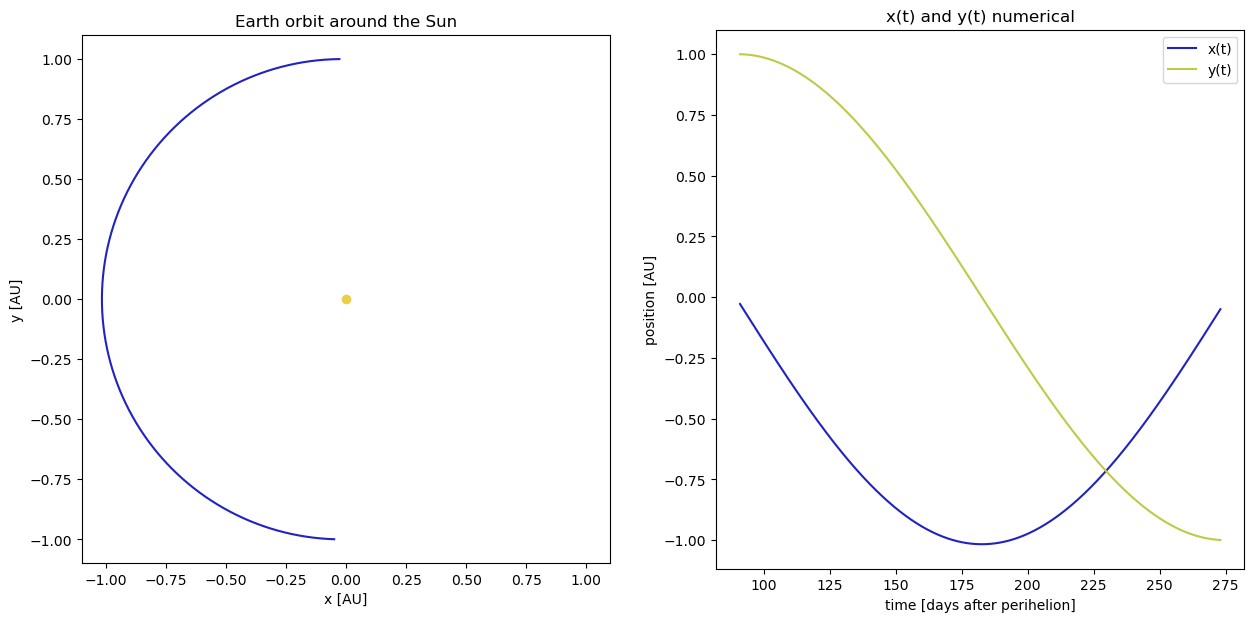

In [73]:
# Data taking period: 
# t0 - beginning in days after 3rd January (perihelion)
# T  - duration of data taking beginngin at t0 in days
t0 = 91
T  = 182

# Define solar angles calculator for Gran Sasso
GranSasso = SolarAngles(latitude=latitude_gs, t0=t0, T=T)


# Calculate orbital positions
times, coords = GranSasso.orbit()
x, y = coords.T[:2]
dist = np.sqrt(x**2 + y**2)     # Earth-Sun distance r in AU



# Plot orbit and angles for data taking period
if True:
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].plot(x, y, color='#2123C1')
    ax[0].plot([0], [0], 'o', color='#E9D047', label='Sun')
    ax[0].set_xlim(-1.1, 1.1)
    ax[0].set_ylim(-1.1, 1.1)
    ax[0].set_aspect('equal')
    ax[0].set_xlabel('x [AU]')
    ax[0].set_ylabel('y [AU]')
    ax[0].set_title('Earth orbit around the Sun')
    

    ax[1].plot(times, x, label='x(t)', color='#2123C1')
    ax[1].plot(times, y, label='y(t)', color='#BECA48')
    # plt.xlim(-pi, pi)
    ax[1].set_xlabel('time [days after perihelion]')
    ax[1].set_ylabel('position [AU]')
    ax[1].set_title('x(t) and y(t) numerical')
    ax[1].legend()

    plt.show()

Zoom in on time-varying incident angle and angular historgram over data taking period.

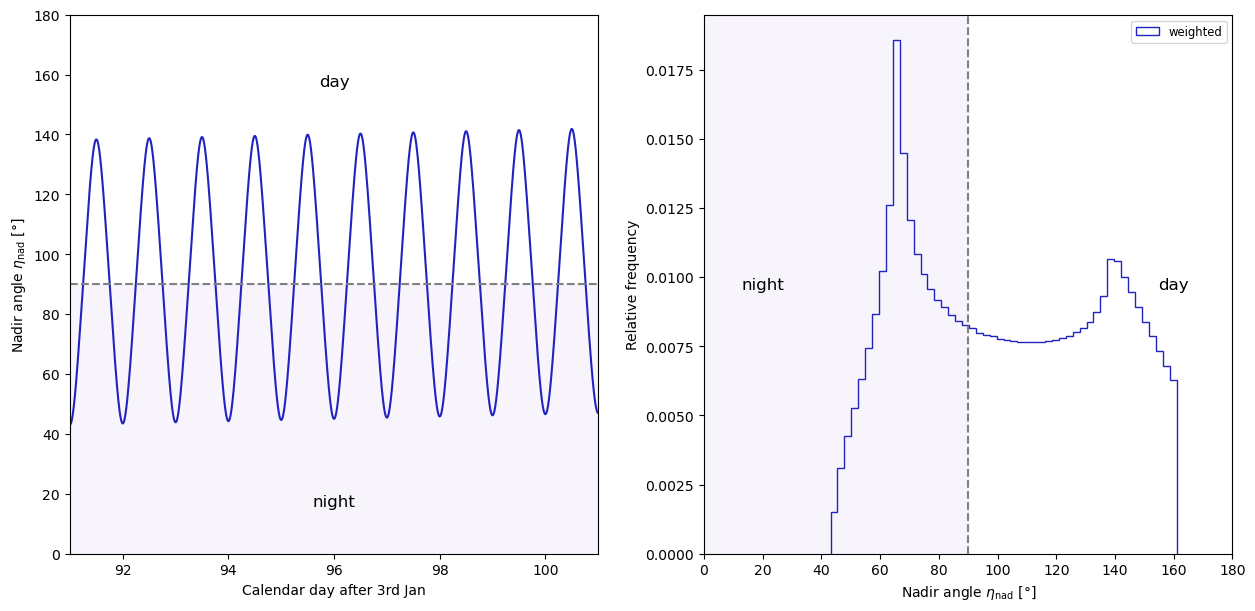

Sum of weights (data taking flux/average annual flux): 0.9788082744991009


In [77]:
# Calculate nadir angles in data taking period
times, nads = GranSasso.nadir_angles()
nads *= 180 / np.pi    # convert angles to degrees



# Plot nadir angle as a function of time
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].plot(times, nads, color='#2123C1')
ax[0].axhline(90, ls='--', color='gray')
ax[0].axhspan(0, 90, color='#792BB1', alpha=0.05)
ax[0].set_ylim(0, 180)
ax[0].text(t0+5, 160, 'day', ha='center', va='top', size='large')
ax[0].text(t0+5, 20, 'night', ha='center', va='top', size='large')
ax[0].set_xlabel("Calendar day after 3rd Jan")
ax[0].set_ylabel(r'Nadir angle $\eta_{\rm nad}\ [\degree]$')
ax[0].set_xlim(t0,t0+10)
# ax[0].set_xlim(t0,t0+T)



# Bin the nadir angles and weight by the inverse square of the Earth-Sun distance to account for the variation in solar flux.
# ax[1].hist(nads, density=True, bins=50, histtype='step', ls='--', label='unweighted')                 # density=False creates absolute counts
ax[1].hist(nads, weights=1/np.pow(dist,2), density=True, bins=50, histtype='step', label='weighted', color='#2123C1')  # density=False would make counts
ax[1].axvline(90, ls='--', color='gray')
ax[1].axvspan(0, 90, color='#792BB1', alpha=0.05)
ax[1].text(20, 0.01, 'night', ha='center', va='top', size='large')
ax[1].text(160, 0.01, 'day', ha='center', va='top', size='large')
ax[1].set_xlim(0, 180)
ax[1].set_ylabel('Relative frequency')
ax[1].set_xlabel(r'Nadir angle $\eta_{\rm nad}\ [\degree]$')
ax[1].legend(fontsize='small')
plt.show()


cnadirs, weights = GranSasso.cnadir_hist(bins=50)
# print(cnadirs, weights)
print("Sum of weights (data taking flux/average annual flux):", sum(weights))

## Night time only histogram

In [55]:
cnadirs, weights = GranSasso.cnadir_hist(bins=50)
cnadirs > 0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [56]:
# np.putmask(weights, cnadirs < 0, 0)  
# print(weights)

cnadirs_night = cnadirs[cnadirs > 0]
weights_night = weights[cnadirs > 0]

weights_night /= sum(weights_night)  # Normalize weights to sum to 1
nadirs_night = np.arccos(cnadirs_night) * 180 / np.pi  # Convert cnadirs to nadir angles in degrees

print("Night nadirs (degrees):", nadirs_night)
print("Sum of night weights:", weights_night.sum())

Night nadirs (degrees): [44.28747199 46.64469347 49.00191494 51.35913641 53.71635788 56.07357936
 58.43080083 60.7880223  63.14524377 65.50246525 67.85968672 70.21690819
 72.57412966 74.93135114 77.28857261 79.64579408 82.00301555 84.36023703
 86.7174585  89.07467997]
Sum of night weights: 1.0


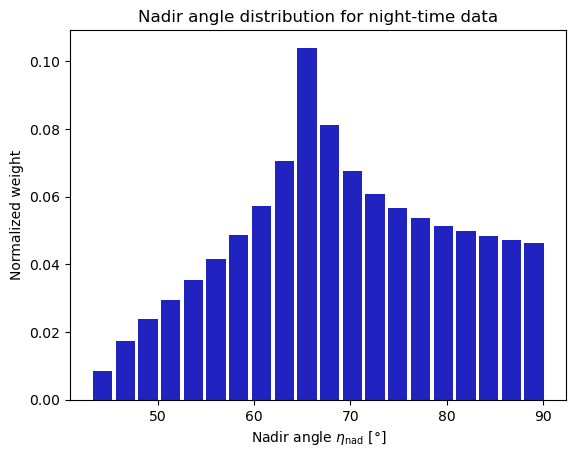

In [74]:
plt.bar(nadirs_night, weights_night, width=2, color='#2123C1')
plt.xlabel(r'Nadir angle $\eta_{\rm nad}\ [\degree]$')
plt.ylabel('Normalized weight')
plt.title('Nadir angle distribution for night-time data')
plt.show()